方法主要是基于正则化(Regularization-based，或称 Selective Synaptic Plasticity)的技术方向

该技术方向的核心思想是在损失函数中加入正则项：$\mathcal{L}_{\text{new}}^\prime(\boldsymbol{\theta}) = \mathcal{L}_{\text{new}}(\boldsymbol{\theta}) + \lambda \sum_{i} \Omega_i(\theta_i^\prime - \theta_i)^2$。不同方法之间的主要区别在于如何计算参数对旧任务的重要性评估权重 $\Omega_i$

EWC(Elastic Weight Consolidation)利用Fisher信息矩阵(Fisher Information Matrix)的对角线元素来评估模型参数对旧任务的重要性。如果某个参数对旧任务很重要(即 Fisher 值较大)，在训练新任务时改变该参数就会受到更大的惩罚。  

MAS(Memory Aware Synapses)不依赖于数据真实标签计算Loss的梯度，而是通过计算模型输出（通常是输出的 L2-Norm）对参数的局部梯度来衡量敏感度。输出对某个参数越敏感，该参数的权重就被定得越高。

SI(Synaptic Intelligence)在整个训练轨迹上在线计算参数重要性。它通过积分计算每个参数的更新在训练过程中对损失函数（Loss）下降的累计贡献（Path Integral），贡献越大的参数在后续任务中被保护得越好。

RWalk(Riemannian Walk)一种进阶的方法，结合了 EWC 的 Fisher 信息矩阵视角与 SI 的路径积分思想，在黎曼流形上更为严谨且动态地衡量参数的重要性。  

SCP(Sliced Cramer Preservation)利用 Sliced Cramer 距离来衡量特征空间。它的主要目标是约束网络在学习新任务时，旧任务数据的网络层输出分布(或特征分布)尽量不要发生严重偏移。

环境准备

In [3]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import copy
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
	print("Using GPU:", torch.cuda.get_device_name(0))
	torch.cuda.manual_seed(42)

Using GPU: NVIDIA GeForce RTX 5080


# 通用组件：保存参数与计算正则化惩罚

In [4]:
def get_current_parameters(model):
    # 提取模型当前的参数字典，用于保存旧任务训练完后的最优参数(θ*)
    params = {}
    for name, param in model.named_parameters():
        if param.requires_grad:
            params[name] = param.data.clone()
    return params

def compute_regularization_penalty(model, omega, old_optimized_params):
    #计算正则化惩罚项： \sum \omega_i * (\theta_i - \theta_i^*)^2
    penalty = 0.0
    for name, param in model.named_parameters():
        if param.requires_grad and name in omega and name in old_optimized_params:
            # (当前参数 - 旧任务最优参数)^2 * 重要性权重
            diff = param - old_optimized_params[name]
            penalty += (omega[name] * (diff ** 2)).sum()
    return penalty

# EWC 组件

利用真实标签计算 CrossEntropy Loss，通过反向传播得到梯度，梯度的平方即为 Fisher 信息矩阵的对角线近似，作为 $\Omega$

In [5]:
def compute_ewc_omega(model, dataloader, device):
    
    # 计算 EWC 的参数重要性矩阵 Omega，需要在当前任务训练结束后调用
    model.eval()
    omega = {}
    
    # 初始化 omega 为 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            omega[name] = torch.zeros_like(param.data).to(device)
            
    criterion = nn.CrossEntropyLoss()
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        model.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # 计算梯度
        
        # 累加梯度的平方
        for name, param in model.named_parameters():
            if param.requires_grad and param.grad is not None:
                omega[name] += (param.grad.data ** 2) / len(dataloader)
                
    return omega

# MAS 组件

不需要真实标签（无监督）。它计算模型输出结果的 L2-Norm，并求该 Norm 对参数的梯度，梯度的绝对值作为 $\Omega$

In [6]:
def compute_mas_omega(model, dataloader, device):
    # 计算 MAS 的参数重要性矩阵 Omega，需要在当前任务训练【结束后】调用
    model.eval()
    omega = {}
    
    for name, param in model.named_parameters():
        if param.requires_grad:
            omega[name] = torch.zeros_like(param.data).to(device)
            
    for inputs, _ in dataloader: # 不需要真实的 labels
        inputs = inputs.to(device)
        
        model.zero_grad()
        outputs = model(inputs)
        
        # MAS 的核心：计算网络输出的 L2-Norm 的均值
        # dim=1 表示在类别维度上求 norm
        loss = outputs.pow(2).sum(dim=1).mean() 
        loss.backward()
        
        # 累加梯度的绝对值 (MAS 论文使用的是梯度的绝对值)
        for name, param in model.named_parameters():
            if param.requires_grad and param.grad is not None:
                omega[name] += param.grad.data.abs() / len(dataloader)
                
    return omega

# SI 组件

在训练的每个 Step 追踪参数的移动轨迹

In [7]:
class SynapticIntelligence:
    def __init__(self, model):
        self.model = model
        self.W = {}       # 记录参数更新带来的路径积分 (Path Integral)
        self.p_old = {}   # 记录上一步的参数值
        self.omega = {}   # 最终的重要性矩阵
        self.epsilon = 0.1 # 防止分母为0的极小值
        
        # 初始化字典
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.W[name] = torch.zeros_like(param.data)
                self.p_old[name] = param.data.clone()
                self.omega[name] = torch.zeros_like(param.data)

    def update_W(self):
        # 在每个 batch 的 optimizer.step() 之后调用，用于累积梯度对参数移动的贡献
        for name, param in self.model.named_parameters():
            if param.requires_grad and param.grad is not None:
                # W = W - grad * (当前参数 - 上一步参数)
                # 注意梯度方向是下降方向，所以这里用负梯度衡量对 loss 下降的贡献
                self.W[name] -= param.grad.data * (param.data - self.p_old[name])
                # 更新旧参数为当前参数，准备迎接下一个 step
                self.p_old[name] = param.data.clone()

    def update_omega(self, old_optimized_params):
        #当前任务训练结束后调用，计算最终的 Omega
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                # Delta_theta: 整个任务训练前后参数的总变化量
                delta_theta = param.data - old_optimized_params[name]
                
                # Omega = W / (Delta_theta^2 + epsilon)
                current_omega = self.W[name] / (delta_theta ** 2 + self.epsilon)
                
                # 将新计算的 omega 累加到历史的 omega 中
                self.omega[name] += current_omega
                
                # 为下一个新任务重置 W
                self.W[name] = torch.zeros_like(param.data)

# RWalk 组件

RWalk 可以看作是 EWC 和 SI 的结合。$\Omega_{RWalk} = F + \frac{W}{\frac{1}{2} F \Delta\theta^2 + \epsilon}$，其中 $F$ 是 Fisher 矩阵，$W$ 是路径积分

In [8]:
class RiemannianWalk:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        
        self.W = {}       # 类似 SI，记录参数更新带来的路径积分
        self.p_old = {}   # 上一步的参数
        self.fisher = {}  # 类似 EWC，记录 Fisher 信息矩阵
        self.omega = {}   # 最终的 RWalk 重要性矩阵
        self.epsilon = 0.1
        
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.W[name] = torch.zeros_like(param.data).to(device)
                self.p_old[name] = param.data.clone()
                self.fisher[name] = torch.zeros_like(param.data).to(device)
                self.omega[name] = torch.zeros_like(param.data).to(device)

    def update_W(self):
        # 在 optimizer.step() 之后调用，累积路径积分 W
        for name, param in self.model.named_parameters():
            if param.requires_grad and param.grad is not None:
                # 记录负梯度方向上参数走过的距离
                self.W[name] -= param.grad.data * (param.data - self.p_old[name])
                self.p_old[name] = param.data.clone()

    def compute_fisher(self, dataloader):
        #当前任务训练结束后调用，计算当前任务的 Fisher 信息矩阵
        self.model.eval()
        criterion = nn.CrossEntropyLoss()
        
        # 临时清空当前任务的 fisher
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.fisher[name].zero_()
                
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            self.model.zero_grad()
            outputs = self.model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            
            for name, param in self.model.named_parameters():
                if param.requires_grad and param.grad is not None:
                    self.fisher[name] += (param.grad.data ** 2) / len(dataloader)

    def update_omega(self, old_optimized_params):
        # 当前任务训练结束后调用，结合 Fisher 和 W 计算 RWalk 的 Omega
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                delta_theta = param.data - old_optimized_params[name]
                
                # RWalk 核心公式分母：0.5 * Fisher * (\Delta \theta)^2 + epsilon
                denominator = 0.5 * self.fisher[name] * (delta_theta ** 2) + self.epsilon
                
                # W / 分母
                scores = self.W[name] / denominator
                
                # 最终的 Omega 是 Fisher 加上得分
                self.omega[name] += self.fisher[name] + scores
                
                # 为下一个新任务重置 W
                self.W[name].zero_()

# SCP 组件

不直接评估“哪个参数重要”，而是约束新模型在旧任务数据上的输出分布与旧模型保持一致

In [9]:
def get_random_projections(d, num_slices, device):
    # 生成用于 Sliced Cramer 距离的随机投影矩阵
    # d 是模型输出的维度 (例如分类数)，num_slices 是投影的切片数量
    projections = torch.randn(d, num_slices).to(device)
    # L2 归一化
    projections = projections / torch.sqrt(torch.sum(projections ** 2, dim=0, keepdim=True))
    return projections

def compute_scp_loss(outputs_new, outputs_old, num_slices=100):
    # 计算 SCP 正则化 Loss (Sliced Cramer Distance)，outputs_new: 当前训练模型在当前 batch 的输出，outputs_old: 冻结的旧模型在当前 batch 的输出
    batch_size, d = outputs_new.size()
    device = outputs_new.device
    
    # 1. 对网络输出进行 Softmax，得到概率分布
    p_new = torch.softmax(outputs_new, dim=1)
    p_old = torch.softmax(outputs_old, dim=1)
    
    # 2. 生成随机投影矩阵 (维度: 类别数 x 切片数)
    projections = get_random_projections(d, num_slices, device)
    
    # 3. 将高维概率分布投影到一维切片上
    # projected shape: (batch_size, num_slices)
    proj_new = torch.matmul(p_new, projections)
    proj_old = torch.matmul(p_old, projections)
    
    # 4. 排序：计算 Cramer 距离需要对一维分布进行排序
    proj_new_sorted, _ = torch.sort(proj_new, dim=0)
    proj_old_sorted, _ = torch.sort(proj_old, dim=0)
    
    # 5. 计算两组有序投影之间的 L2 距离的平方，并在 batch 和 slice 上取均值
    # 这就是 Sliced Cramer 距离的近似
    scp_loss = torch.mean((proj_new_sorted - proj_old_sorted) ** 2)
    
    return scp_loss

# 准备 Permuted MNIST 数据集

Permuted MNIST 是一个非常经典的设定。它的逻辑是：任务 1 就是普通的 MNIST 手写数字识别；任务 2 则是把所有图片的像素位置按照一个固定的随机顺序打乱(Permute)；任务 3 再换一种打乱顺序……以此类推。由于像素位置全变了，模型会觉得这是一个全新的任务，从而容易“忘掉”之前的分类模式。

训练集

In [10]:
def get_permuted_mnist_train(num_tasks=5, batch_size=128, data_dir='./data'):
    # 生成多个 Permuted MNIST 任务的数据加载器。num_tasks: 任务的数量
    # 1. 下载并加载原始 MNIST 训练集
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)) # MNIST 标准化参数
    ])
    
    mnist_train = datasets.MNIST(data_dir, train=True, download=True, transform=transform)
    
    # 提取所有数据和标签 (将 28x28 展平为 784)
    x_train = mnist_train.data.float().view(-1, 784) / 255.0
    # 手动应用上面的标准化
    x_train = (x_train - 0.1307) / 0.3081
    y_train = mnist_train.targets
    
    dataloaders = []
    permutations = [] # 保存每个任务的打乱顺序（可用于可视化或测试）
    
    for task_id in range(num_tasks):
        if task_id == 0:
            # 任务 0: 原始顺序，不打乱
            perm = np.arange(784)
        else:
            # 任务 1~N: 随机打乱像素顺序
            perm = np.random.permutation(784)
            
        permutations.append(perm)
        
        # 按照当前任务的 perm 打乱图像的像素维度
        x_task = x_train[:, perm]
        
        # 封装为 TensorDataset 和 DataLoader
        dataset = TensorDataset(x_task, y_train)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        dataloaders.append(loader)
        
        print(f"Task {task_id} Dataloader prepared.")
        
    return dataloaders, permutations

# 生成 5 个任务的数据
train_dataloaders, permutations = get_permuted_mnist_train(num_tasks=5)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.56MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 146kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Task 0 Dataloader prepared.
Task 1 Dataloader prepared.
Task 2 Dataloader prepared.
Task 3 Dataloader prepared.
Task 4 Dataloader prepared.


测试集

In [11]:
def get_permuted_mnist_test(permutations, batch_size=128, data_dir='./data'):
    # 使用训练集生成的打乱顺序 (permutations) 来生成对应的测试集
    # 1. 下载并加载 MNIST 测试集 (train=False)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    mnist_test = datasets.MNIST(data_dir, train=False, download=True, transform=transform)
    
    # 提取并标准化
    x_test = mnist_test.data.float().view(-1, 784) / 255.0
    x_test = (x_test - 0.1307) / 0.3081
    y_test = mnist_test.targets
    
    test_dataloaders = []
    
    # 2. 严格按照训练集的 permutations 列表来打乱测试集
    for task_id, perm in enumerate(permutations):
        # 按照当前任务的 perm 打乱图像的像素维度
        x_task = x_test[:, perm]
        
        # 封装为 TensorDataset 和 DataLoader (测试集不需要 shuffle)
        dataset = TensorDataset(x_task, y_test)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        test_dataloaders.append(loader)
        
        print(f"Task {task_id} Test Dataloader prepared.")
        
    return test_dataloaders

# 生成测试集 Dataloaders (必须传入刚才训练集生成的 permutations)
test_dataloaders = get_permuted_mnist_test(permutations)

Task 0 Test Dataloader prepared.
Task 1 Test Dataloader prepared.
Task 2 Test Dataloader prepared.
Task 3 Test Dataloader prepared.
Task 4 Test Dataloader prepared.


可视化 permuted Mnist

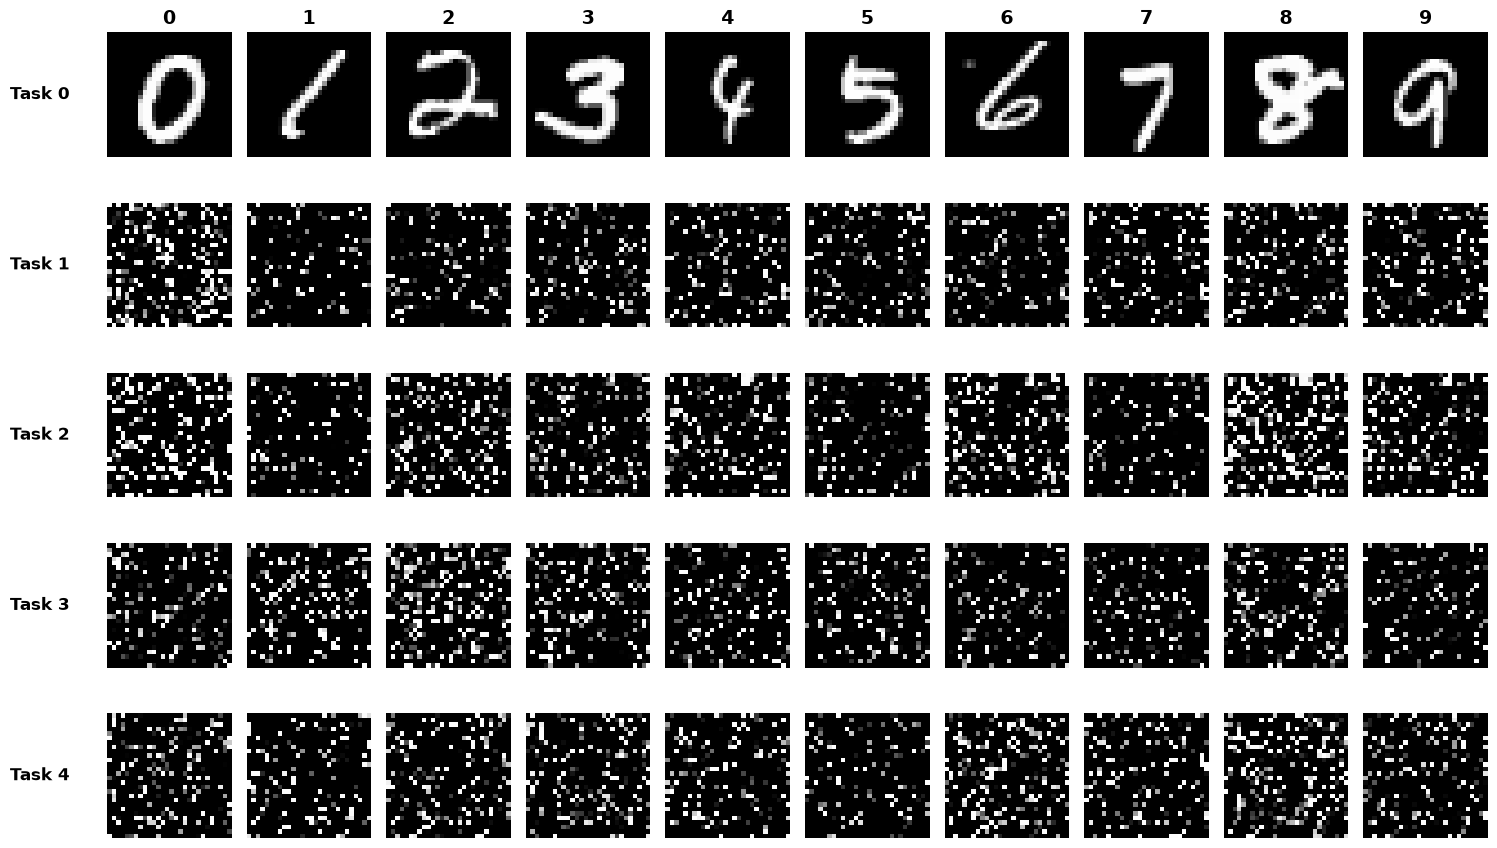

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 我们有 5 个任务，10 个类别 (0-9)
num_tasks = len(train_dataloaders)
num_classes = 10

# 创建画板，行数为任务数，列数为类别数 (10列)
fig, axes = plt.subplots(num_tasks, num_classes, figsize=(1.5 * num_classes, 1.8 * num_tasks))

for task_id in range(num_tasks):
    loader = train_dataloaders[task_id]
    
    # 字典：用于收集当前任务下，0-9 每个类别各一张图片
    found_images = {}
    
    # 遍历当前 loader，直到 10 个数字全集齐
    for images, labels in loader:
        for i in range(len(labels)):
            label = labels[i].item()
            # 如果这个类别的图片还没收录，就存下来
            if label not in found_images:
                found_images[label] = images[i].numpy()
            
            # 如果 0-9 全凑齐了，直接跳出循环
            if len(found_images) == num_classes:
                break
        if len(found_images) == num_classes:
            break
            
    # 按 0 到 9 的顺序，把收集到的图片画出来
    for label in range(num_classes):
        ax = axes[task_id, label]
        img = found_images[label]
        
        # 反标准化并 reshape 为 28x28
        img = img * 0.3081 + 0.1307
        img = np.clip(img, 0, 1)
        img = img.reshape(28, 28)
        
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        
        # 顶层（第一行）添加列标题：显示是哪个数字
        if task_id == 0:
            ax.set_title(f"{label}", fontsize=14, fontweight='bold')
            
        # 最左侧（第一列）添加行标题：显示是哪个任务
        if label == 0:
            ax.text(-0.3, 0.5, f"Task {task_id}", transform=ax.transAxes, 
                    fontsize=12, fontweight='bold', va='center', ha='right')

plt.tight_layout()
plt.show()

# 构建基础网络模型

处理 Permuted MNIST，通常不需要用卷积神经网络(CNN)，因为像素的局部空间结构已经被打乱了(CNN 的卷积核找不到规律)。因此，使用一个简单的多层感知机 (MLP) 即可。

In [13]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=400, num_classes=10):
        super(SimpleMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        # 确保输入是展平的 [batch_size, 784]
        x = x.view(x.size(0), -1) 
        return self.model(x)

# 训练

每用一个方法训练，都要重新初始化一个模型和优化器

In [ ]:
criterion = nn.CrossEntropyLoss()
epochs_per_task = 10

def get_new_model():
    #每次调用返回一个全新的模型和优化器
    model = SimpleMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    return model, optimizer

评估函数

In [15]:
def evaluate_model(model, dataloaders, current_task_id, device):
    # 测试模型在 Task 0 到 Task current_task_id 上的准确率
    model.eval()
    accuracies = []
    
    with torch.no_grad():
        # 遍历从任务 0 到当前刚学完的任务
        for t in range(current_task_id + 1):
            correct = 0
            total = 0
            
            for inputs, labels in dataloaders[t]:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                
                # 获取预测类别
                _, predicted = torch.max(outputs.data, 1)
                
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
            acc = correct / total
            accuracies.append(acc)
            
    return accuracies

## baseline

In [ ]:
print("========== 开始 Baseline 训练与评估 ==========")
model, optimizer = get_new_model()

for task_id in range(num_tasks):
    print(f"Training Task: {task_id}")
    model.train()
    for epoch in range(epochs_per_task):
        for inputs, labels in train_dataloaders[task_id]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    # 评分
    accs = evaluate_model(model, test_dataloaders, task_id, device)
    # 打印评分结果
    for t, acc in enumerate(accs):
        print(f"在第{task_id}任务上训练后，在 Task {t} 上的准确率: {acc:.2f}")

========== 开始 Baseline 训练与评估 ==========
Training Task: 0
在第0上训练后，在 Task 0 上的准确率: 0.97
Training Task: 1
在第1上训练后，在 Task 0 上的准确率: 0.91
在第1上训练后，在 Task 1 上的准确率: 0.98
Training Task: 2
在第2上训练后，在 Task 0 上的准确率: 0.86
在第2上训练后，在 Task 1 上的准确率: 0.95
在第2上训练后，在 Task 2 上的准确率: 0.98
Training Task: 3
在第3上训练后，在 Task 0 上的准确率: 0.76
在第3上训练后，在 Task 1 上的准确率: 0.89
在第3上训练后，在 Task 2 上的准确率: 0.95
在第3上训练后，在 Task 3 上的准确率: 0.97
Training Task: 4
在第4上训练后，在 Task 0 上的准确率: 0.69
在第4上训练后，在 Task 1 上的准确率: 0.81
在第4上训练后，在 Task 2 上的准确率: 0.90
在第4上训练后，在 Task 3 上的准确率: 0.95
在第4上训练后，在 Task 4 上的准确率: 0.97


## EWC

In [ ]:
print("========== 开始 EWC 训练与评估 ==========")
model, optimizer = get_new_model()
lambda_weight = 1000 # 正则化系数，可以根据实验结果适当调大或调小
history_omega = {}
history_optimized_params = {}

for task_id in range(num_tasks):
    print(f"Training Task: {task_id}")
    model.train()
    
    for epoch in range(epochs_per_task):
        for inputs, labels in train_dataloaders[task_id]:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # 加入 EWC 正则化惩罚
            if task_id > 0:
                penalty = compute_regularization_penalty(model, history_omega, history_optimized_params)
                loss += lambda_weight * penalty
                
            loss.backward()
            optimizer.step()
            
    # 计算 Omega 并更新记忆
    current_optimized_params = get_current_parameters(model)
    current_omega = compute_ewc_omega(model, train_dataloaders[task_id], device)
    
    if task_id == 0:
        history_omega = current_omega
    else:
        for name in history_omega.keys():
            history_omega[name] += current_omega[name]
            
    history_optimized_params = current_optimized_params
    
    # 评估
    accs = evaluate_model(model, test_dataloaders, task_id, device)
    for t, acc in enumerate(accs):
        print(f"在第{task_id}任务上训练后，在 Task {t} 上的准确率: {acc:.2f}")

========== 开始 EWC 训练与评估 ==========
Training Task: 0
在第0任务上训练后，在 Task 0 上的准确率: 0.97
Training Task: 1
在第1任务上训练后，在 Task 0 上的准确率: 0.96
在第1任务上训练后，在 Task 1 上的准确率: 0.97
Training Task: 2
在第2任务上训练后，在 Task 0 上的准确率: 0.95
在第2任务上训练后，在 Task 1 上的准确率: 0.97
在第2任务上训练后，在 Task 2 上的准确率: 0.97
Training Task: 3
在第3任务上训练后，在 Task 0 上的准确率: 0.94
在第3任务上训练后，在 Task 1 上的准确率: 0.96
在第3任务上训练后，在 Task 2 上的准确率: 0.97
在第3任务上训练后，在 Task 3 上的准确率: 0.97
Training Task: 4
在第4任务上训练后，在 Task 0 上的准确率: 0.93
在第4任务上训练后，在 Task 1 上的准确率: 0.96
在第4任务上训练后，在 Task 2 上的准确率: 0.96
在第4任务上训练后，在 Task 3 上的准确率: 0.97
在第4任务上训练后，在 Task 4 上的准确率: 0.97


## MAS

In [26]:
print("========== 开始 MAS 训练与评估 ==========")
model, optimizer = get_new_model()
lambda_weight = 0.1 # 正则化系数，可以根据实验结果适当调大或调小
history_omega = {}
history_optimized_params = {}

for task_id in range(num_tasks):
    print(f"Training Task {task_id}")
    model.train()
    
    for epoch in range(epochs_per_task):
        for inputs, labels in train_dataloaders[task_id]:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # 加入 MAS 正则化惩罚
            if task_id > 0:
                penalty = compute_regularization_penalty(model, history_omega, history_optimized_params)
                loss += lambda_weight * penalty
                
            loss.backward()
            optimizer.step()
            
    # 计算 MAS Omega 并更新记忆
    current_optimized_params = get_current_parameters(model)
    current_omega = compute_mas_omega(model, train_dataloaders[task_id], device)
    
    if task_id == 0:
        history_omega = current_omega
    else:
        for name in history_omega.keys():
            history_omega[name] += current_omega[name]
            
    history_optimized_params = current_optimized_params
    
    # 评估
    accs = evaluate_model(model, test_dataloaders, task_id, device)
    for t, acc in enumerate(accs):
        print(f"在第{task_id}任务上训练后，在 Task {t} 上的准确率: {acc:.2f}")

========== 开始 MAS 训练与评估 ==========
Training Task 0
在第0任务上训练后，在 Task 0 上的准确率: 0.97
Training Task 1
在第1任务上训练后，在 Task 0 上的准确率: 0.97
在第1任务上训练后，在 Task 1 上的准确率: 0.96
Training Task 2
在第2任务上训练后，在 Task 0 上的准确率: 0.97
在第2任务上训练后，在 Task 1 上的准确率: 0.95
在第2任务上训练后，在 Task 2 上的准确率: 0.94
Training Task 3
在第3任务上训练后，在 Task 0 上的准确率: 0.97
在第3任务上训练后，在 Task 1 上的准确率: 0.94
在第3任务上训练后，在 Task 2 上的准确率: 0.93
在第3任务上训练后，在 Task 3 上的准确率: 0.93
Training Task 4
在第4任务上训练后，在 Task 0 上的准确率: 0.96
在第4任务上训练后，在 Task 1 上的准确率: 0.95
在第4任务上训练后，在 Task 2 上的准确率: 0.93
在第4任务上训练后，在 Task 3 上的准确率: 0.93
在第4任务上训练后，在 Task 4 上的准确率: 0.92


## SI

In [28]:
print("========== 开始 SI 训练与评估 ==========")
model, optimizer = get_new_model()
si = SynapticIntelligence(model)
lambda_weight = 0.1 # 正则化系数，可以根据实验结果适当调大或调小
history_optimized_params = get_current_parameters(model)

for task_id in range(num_tasks):
    print(f"Training Task {task_id}")
    model.train()
    
    for epoch in range(epochs_per_task):
        for inputs, labels in train_dataloaders[task_id]:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # 使用 SI 惩罚
            if task_id > 0:
                penalty = compute_regularization_penalty(model, si.omega, history_optimized_params)
                loss += lambda_weight * penalty 
                
            loss.backward()
            optimizer.step()
            
            # 更新路径积分
            si.update_W()
            
    # 更新 Omega 和最优参数
    si.update_omega(history_optimized_params)
    history_optimized_params = get_current_parameters(model)
    
    # 评估
    accs = evaluate_model(model, test_dataloaders, task_id, device)
    for t, acc in enumerate(accs):
        print(f"在第{task_id}任务上训练后，在 Task {t} 上的准确率: {acc:.2f}")

========== 开始 SI 训练与评估 ==========
Training Task 0
在第0任务上训练后，在 Task 0 上的准确率: 0.97
Training Task 1
在第1任务上训练后，在 Task 0 上的准确率: 0.90
在第1任务上训练后，在 Task 1 上的准确率: 0.98
Training Task 2
在第2任务上训练后，在 Task 0 上的准确率: 0.88
在第2任务上训练后，在 Task 1 上的准确率: 0.95
在第2任务上训练后，在 Task 2 上的准确率: 0.98
Training Task 3
在第3任务上训练后，在 Task 0 上的准确率: 0.73
在第3任务上训练后，在 Task 1 上的准确率: 0.88
在第3任务上训练后，在 Task 2 上的准确率: 0.94
在第3任务上训练后，在 Task 3 上的准确率: 0.98
Training Task 4
在第4任务上训练后，在 Task 0 上的准确率: 0.70
在第4任务上训练后，在 Task 1 上的准确率: 0.81
在第4任务上训练后，在 Task 2 上的准确率: 0.91
在第4任务上训练后，在 Task 3 上的准确率: 0.94
在第4任务上训练后，在 Task 4 上的准确率: 0.97


## RWalk

In [29]:
print("========== 开始 RWalk 训练与评估 ==========")
model, optimizer = get_new_model()
rwalk = RiemannianWalk(model, device)
lambda_weight = 0.1 # 正则化系数，可以根据实验结果适当调大或调小
history_optimized_params = get_current_parameters(model)

for task_id in range(num_tasks):
    print(f"Training Task {task_id}")
    model.train()
    
    for epoch in range(epochs_per_task):
        for inputs, labels in train_dataloaders[task_id]:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            if task_id > 0:
                penalty = compute_regularization_penalty(model, rwalk.omega, history_optimized_params)
                loss += lambda_weight * penalty
                
            loss.backward()
            optimizer.step()
            
            # 记录路径
            rwalk.update_W()
            
    # 计算 Fisher 并更新最终 Omega
    rwalk.compute_fisher(train_dataloaders[task_id])
    rwalk.update_omega(history_optimized_params)
    history_optimized_params = get_current_parameters(model)
    
    # 评估
    accs = evaluate_model(model, test_dataloaders, task_id, device)
    for t, acc in enumerate(accs):
        print(f"在第{task_id}任务上训练后，在 Task {t} 上的准确率: {acc:.2f}")

========== 开始 RWalk 训练与评估 ==========
Training Task 0
在第0任务上训练后，在 Task 0 上的准确率: 0.97
Training Task 1
在第1任务上训练后，在 Task 0 上的准确率: 0.95
在第1任务上训练后，在 Task 1 上的准确率: 0.97
Training Task 2
在第2任务上训练后，在 Task 0 上的准确率: 0.89
在第2任务上训练后，在 Task 1 上的准确率: 0.96
在第2任务上训练后，在 Task 2 上的准确率: 0.98
Training Task 3
在第3任务上训练后，在 Task 0 上的准确率: 0.79
在第3任务上训练后，在 Task 1 上的准确率: 0.92
在第3任务上训练后，在 Task 2 上的准确率: 0.96
在第3任务上训练后，在 Task 3 上的准确率: 0.97
Training Task 4
在第4任务上训练后，在 Task 0 上的准确率: 0.76
在第4任务上训练后，在 Task 1 上的准确率: 0.90
在第4任务上训练后，在 Task 2 上的准确率: 0.93
在第4任务上训练后，在 Task 3 上的准确率: 0.96
在第4任务上训练后，在 Task 4 上的准确率: 0.98


## SCP

In [30]:
print("========== 开始 SCP 训练与评估 ==========")
model, optimizer = get_new_model()
old_model = None
lambda_weight = 10 # 正则化系数，可以根据实验结果适当调大或调小
for task_id in range(num_tasks):
    print(f"Training Task {task_id}")
    
    # 准备 Teacher 模型：冻结上一阶段的网络
    if task_id > 0:
        old_model = copy.deepcopy(model)
        old_model.eval()
        for param in old_model.parameters():
            param.requires_grad = False
            
    model.train()
    for epoch in range(epochs_per_task):
        for inputs, labels in train_dataloaders[task_id]:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # 计算分布距离作为惩罚
            if task_id > 0:
                with torch.no_grad():
                    outputs_old = old_model(inputs)
                
                scp_penalty = compute_scp_loss(outputs, outputs_old, num_slices=100)
                loss += lambda_weight * scp_penalty
                
            loss.backward()
            optimizer.step()
            
    # SCP 不需要更新 Omega，直接评估
    accs = evaluate_model(model, test_dataloaders, task_id, device)
    for t, acc in enumerate(accs):
        print(f"在第{task_id}任务上训练后，在 Task {t} 上的准确率: {acc:.2f}")

========== 开始 SCP 训练与评估 ==========
Training Task 0
在第0任务上训练后，在 Task 0 上的准确率: 0.97
Training Task 1
在第1任务上训练后，在 Task 0 上的准确率: 0.80
在第1任务上训练后，在 Task 1 上的准确率: 0.94
Training Task 2
在第2任务上训练后，在 Task 0 上的准确率: 0.52
在第2任务上训练后，在 Task 1 上的准确率: 0.36
在第2任务上训练后，在 Task 2 上的准确率: 0.94
Training Task 3
在第3任务上训练后，在 Task 0 上的准确率: 0.48
在第3任务上训练后，在 Task 1 上的准确率: 0.39
在第3任务上训练后，在 Task 2 上的准确率: 0.70
在第3任务上训练后，在 Task 3 上的准确率: 0.94
Training Task 4
在第4任务上训练后，在 Task 0 上的准确率: 0.37
在第4任务上训练后，在 Task 1 上的准确率: 0.30
在第4任务上训练后，在 Task 2 上的准确率: 0.48
在第4任务上训练后，在 Task 3 上的准确率: 0.51
在第4任务上训练后，在 Task 4 上的准确率: 0.86
